Running QRF (Base Dataset)...


Horizons: 100%|██████████| 10/10 [01:15<00:00,  7.56s/it]


Running QRF (Alternative Dataset)...


Horizons: 100%|██████████| 10/10 [02:12<00:00, 13.24s/it]


Running XGBoost (Base Dataset)...


...

,Horizon,CRPS,PICP,Interval_Width,RMSE
0,1,15.755362,0.297450,27.465148,52.979495
1,2,15.120904,0.382436,40.758674,53.336925
2,3,14.823454,0.453258,49.188372,53.743582
3,4,14.707055,0.543909,61.085451,54.899144
4,5,15.059566,0.563739,66.352480,56.617752
5,6,15.569199,0.569405,71.284383,58.215268
6,7,16.184140,0.555241,75.419522,60.338585
7,8,16.754409,0.532578,80.171462,62.263983
8,9,17.746728,0.492918,86.804093,65.927239
9,10,17.507141,0.538244,92.491575,66.018404



XGB - Base Dataset


,Horizon,CRPS,PICP,Interval_Width,RMSE
0,1,4.723097,0.869688,48.813702,21.559425
1,2,5.798786,0.662890,36.120716,28.255293
2,3,7.058120,0.750708,49.955948,32.498093
3,4,7.900584,0.722380,55.693497,38.174856
4,5,7.578887,0.728045,63.445175,31.089710
5,6,8.453342,0.679887,64.608582,36.050862
6,7,9.241134,0.696884,76.767349,39.803008
7,8,9.804961,0.677054,83.088600,40.171865
8,9,10.698711,0.708215,93.155434,45.217135
9,10,11.636238,0.668555,88.194298,47.320442



XGB - Alternative Dataset


,Horizon,CRPS,PICP,Interval_Width,RMSE
0,1,4.490369,0.835694,38.756893,21.434129
1,2,5.907307,0.739377,45.231651,27.366016
2,3,7.500905,0.696884,45.557587,34.729558
3,4,8.720028,0.767705,60.185692,46.491174
4,5,7.567679,0.756374,65.344910,31.423321
5,6,8.433063,0.764873,77.217590,35.136013
6,7,9.402922,0.725212,75.561783,41.766766
7,8,10.530546,0.736544,100.833595,41.468412
8,9,10.417067,0.739377,92.241615,43.621314
9,10,11.396741,0.804533,102.716347,49.666977


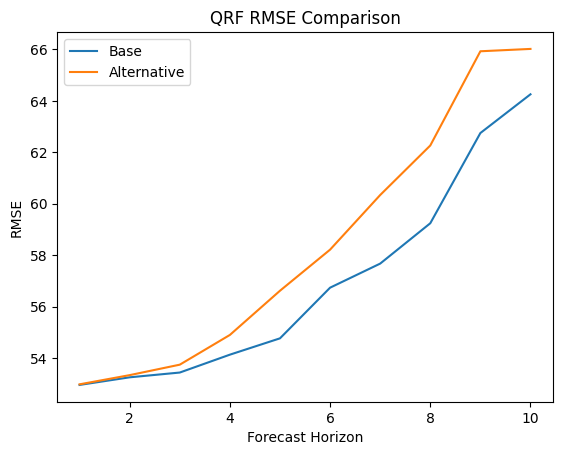

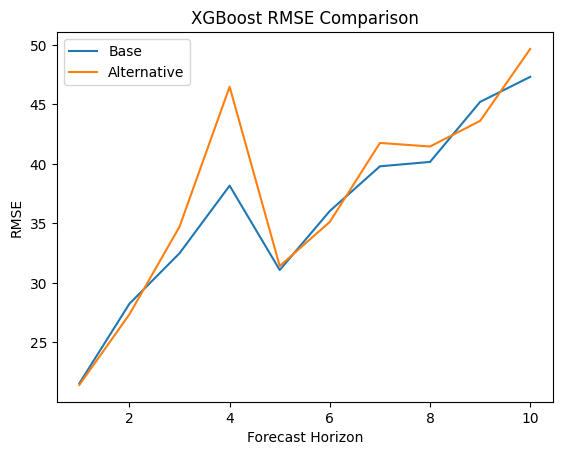

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from prophet import Prophet

from tqdm import tqdm

# ============================================================
# LOAD PROCESSED DATA
# ============================================================

base_data = pd.read_csv("processed_base_dataset.csv", parse_dates=["Date"])
alt_data  = pd.read_csv("processed_alt_dataset.csv", parse_dates=["Date"])

HORIZON = 10
QUANTILES = [0.1, 0.5, 0.9]

# ============================================================
# METRIC FUNCTIONS
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def pinball_loss(y_true, y_pred, q):
    """
    Computes pinball loss for a single quantile.
    """
    error = y_true - y_pred
    return np.mean(np.maximum(q * error, (q - 1) * error))


def crps_approximation(y_true, q_preds, quantiles):
    """
    Approximate CRPS by averaging pinball losses across quantiles.
    """
    total = 0
    for q, pred in zip(quantiles, q_preds):
        total += pinball_loss(y_true, pred, q)
    return total / len(quantiles)


def picp(y_true, lower, upper):
    """
    Prediction Interval Coverage Probability.
    """
    inside = np.logical_and(y_true >= lower, y_true <= upper)
    return np.mean(inside)


def interval_width(lower, upper):
    return np.mean(upper - lower)

# ============================================================
# WALK-FORWARD VALIDATION FUNCTION
# ============================================================

def walk_forward(dataset, model_type="qrf"):
    
    results = []
    
    split_index = int(len(dataset) * 0.8)
    
    for h in tqdm(range(1, HORIZON + 1), desc="Horizons"):
        
        target_col = f"Target_t+{h}"
        
        X = dataset.drop(columns=["Date"] + 
                         [f"Target_t+{i}" for i in range(1, HORIZON+1)])
        y = dataset[target_col]
        
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
        
        quantile_predictions = []
        
        for q in QUANTILES:
            
            if model_type == "qrf":
                
                model = RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=5,
                    random_state=42
                )
                
                model.fit(X_train.values, y_train.values)

                # Collect predictions from each tree
                all_tree_preds = np.array([
                    tree.predict(X_test.values)
                    for tree in model.estimators_
                ])

                # Compute quantile per observation
                preds = np.percentile(
                    all_tree_preds,
                    q * 100,
                    axis=0
                )
                
                preds = np.mean(preds)
                preds = np.repeat(preds, len(y_test))
                
            elif model_type == "xgb":
                
                model = XGBRegressor(
                    objective="reg:quantileerror",
                    quantile_alpha=q,
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=4,
                    random_state=42
                    n_jobs=1
                )
                
                model.fit(X_train.values, y_train.values)
                preds = model.predict(X_test.values)
                
            quantile_predictions.append(preds)
        
        lower = quantile_predictions[0]
        median = quantile_predictions[1]
        upper = quantile_predictions[2]
        
        crps_val = crps_approximation(y_test, quantile_predictions, QUANTILES)
        picp_val = picp(y_test, lower, upper)
        width_val = interval_width(lower, upper)
        rmse_val = rmse(y_test, median)
        
        results.append({
            "Horizon": h,
            "CRPS": crps_val,
            "PICP": picp_val,
            "Interval_Width": width_val,
            "RMSE": rmse_val
        })
    
    return pd.DataFrame(results)

# ============================================================
# RUN MODELS
# ============================================================

print("Running QRF (Base Dataset)...")
qrf_base_results = walk_forward(base_data, model_type="qrf")

print("Running QRF (Alternative Dataset)...")
qrf_alt_results = walk_forward(alt_data, model_type="qrf")

print("Running XGBoost (Base Dataset)...")
xgb_base_results = walk_forward(base_data, model_type="xgb")

print("Running XGBoost (Alternative Dataset)...")
xgb_alt_results = walk_forward(alt_data, model_type="xgb")

# ============================================================
# DISPLAY RESULTS TABLES
# ============================================================

print("\nQRF - Base Dataset")
display(qrf_base_results)

print("\nQRF - Alternative Dataset")
display(qrf_alt_results)

print("\nXGB - Base Dataset")
display(xgb_base_results)

print("\nXGB - Alternative Dataset")
display(xgb_alt_results)

# ============================================================
# PLOT RMSE COMPARISON
# ============================================================

plt.figure()
plt.plot(qrf_base_results["Horizon"], qrf_base_results["RMSE"])
plt.plot(qrf_alt_results["Horizon"], qrf_alt_results["RMSE"])
plt.title("QRF RMSE Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.legend(["Base", "Alternative"])
plt.show()

plt.figure()
plt.plot(xgb_base_results["Horizon"], xgb_base_results["RMSE"])
plt.plot(xgb_alt_results["Horizon"], xgb_alt_results["RMSE"])
plt.title("XGBoost RMSE Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.legend(["Base", "Alternative"])
plt.show()


In [10]:
print("QRF Base Data averages")
display(qrf_base_results.mean())

print("QRF Alt Data averages")
display(qrf_alt_results.mean())

print("XGB Base Data averages")
display(xgb_base_results.mean())

print("XGB Alt Data averages")
display(xgb_alt_results.mean())

QRF Base Data averages


Horizon            5.500000
CRPS              15.491606
PICP               0.504533
Interval_Width    63.457578
RMSE              56.920017
dtype: float64

QRF Alt Data averages


Horizon            5.500000
CRPS              15.922796
PICP               0.492918
Interval_Width    65.102116
RMSE              58.434038
dtype: float64

XGB Base Data averages


Horizon            5.500000
CRPS               8.289386
PICP               0.716431
Interval_Width    65.984329
RMSE              36.014069
dtype: float64

XGB Alt Data averages


Horizon            5.500000
CRPS               8.436663
PICP               0.756657
Interval_Width    70.364769
RMSE              37.310368
dtype: float64